
LinearRegression
MAE: 5.467544176290204
MSE: 55.525263461917355
R2: 0.575541711199034

Ridge
MAE: 5.46747548624175
MSE: 55.524909222646926
R2: 0.575544419151868

RandomForest
MAE: 4.569643750000001
MSE: 33.47825418125
R2: 0.7440782520273257

ИТОГ:
              Model       MAE        MSE        R2
0  LinearRegression  5.467544  55.525263  0.575542
1             Ridge  5.467475  55.524909  0.575544
2      RandomForest  4.569644  33.478254  0.744078


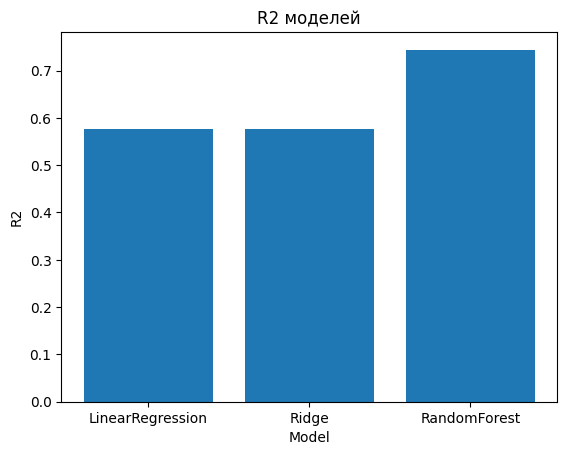

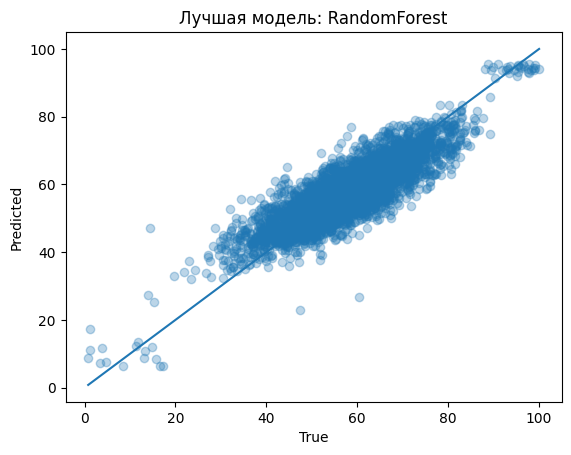

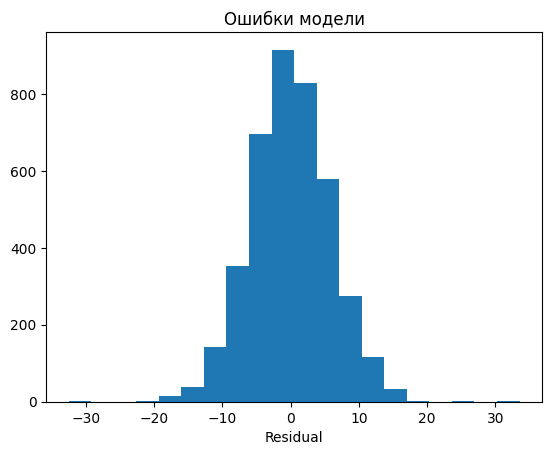

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(r"C:\Users\User\Desktop\Student Performance and Behaviour.csv")
df = df.sample(20000, random_state=42)
target = "Final_Exam_Score"
df = df.drop("Student_ID", axis=1)
X = df.drop(target, axis=1)
y = df[target]

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=40
)
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(
        n_estimators=20,      
        random_state=40,
        n_jobs=-1            
    )
}
results = []
best_pred = None
best_name = None
best_r2 = -999

for name, reg in models.items():
    model = Pipeline([
        ("preprocess", preprocess),
        ("regressor", reg)
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"\n{name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("R2:", r2)
    results.append([name, mae, mse, r2])
    if r2 > best_r2:
        best_r2 = r2
        best_pred = pred
        best_name = name
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2"])

print("\nИТОГ:")
print(results_df)

plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.title("R2 моделей")
plt.xlabel("Model")
plt.ylabel("R2")
plt.show()
plt.figure()
plt.scatter(y_test, best_pred, alpha=0.3)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title(f"Лучшая модель: {best_name}")
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()
residuals = y_test - best_pred
plt.figure()
plt.hist(residuals, bins=20)
plt.title("Ошибки модели")
plt.xlabel("Residual")
plt.show()